# Volume-pair analyser  (v3)

Adapted to the full metrics suite of the maths companion document, with three-figure / CSV-table output:

**Figures (square, no slice panels):**
- `{name}_clean.png` — bimodal histogram with marginals only
- `{name}_materials.png` — + ground-truth material markers
- `{name}_full.png` — + GMM ellipses

**Table (CSV, suitable for supplementary materials):**
- `{name}_metrics.csv` — Section / Eq / Metric / GMM (v1) / Label-anchored (v3) / Notes

Computed metrics:
- **Shape** (`detect_artifact_signatures`) — S_h, S_v, S_d, A_x, Δ_n.
- **Quality, GMM-based (v1)** (`evaluate_histogram_quality`) — ε_k, σ_x, σ_n, CE, DB.
- **Quality, label-anchored (v3)** (`compute_histogram_metrics_morphology_aware`) — same vocabulary, plus the per-cluster elongation E_k, pairwise overlaps O_ab, and an optional per-spatial-region table for anomaly detection.

Where the GMM and label-anchored values disagree by more than 1.5×, the discrepancy ratio appears in the Notes column of the CSV — making the GMM-failure mode of §3 of the maths companion immediately visible.

## Usage

Run the cells top-to-bottom.  The next cell defines the entire `analyse_volume_pair` function (public API plus all internal helpers, in one self-contained cell).  The two example cells below demonstrate clean and dirty-with-reference runs.

In [1]:
"""
analyse_volume_pair  (v3 — three-figure / CSV-table output)
─────────────────────────────────────────────────────────────
Adapted to the full metrics suite of the maths companion document and
restructured for publication-style output:

    {name}_clean.png      bimodal histogram with marginals only
    {name}_materials.png  histogram + ground-truth material markers
    {name}_full.png       histogram + GT markers + GMM ellipses
    {name}_metrics.csv    full metric table (Section / Eq / Metric /
                          GMM (v1) / Label-anchored (v3) / Notes)

Histogram panels are square in core proportion (default 7×7 in figure
with a 4:1 height ratio between heatmap and top marginal, giving a
visually square heatmap).  No volume slices are drawn and the metric
table is no longer rendered inside the figure — it is written to disk
as a CSV that the caller can post-process or include as a supplementary
table.

The public signature is otherwise unchanged from v2 in its core
arguments (vol_xray, vol_neutron, phantom_obj, etc.); existing notebook
calls continue to work, they will produce three figures with
auto-generated filenames if `output_name` is not supplied.
"""
from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgs
from matplotlib.patches import Ellipse


# ─────────────────────────────────────────────────────────────────────────────
#  Public API
# ─────────────────────────────────────────────────────────────────────────────
def analyse_volume_pair(
    # ── Volume input (choose ONE of the three input modes) ────────────────────
    vol_xray:        Optional[np.ndarray] = None,
    vol_neutron:     Optional[np.ndarray] = None,
    path_xray:       Optional[Union[str, Path]] = None,
    path_neutron:    Optional[Union[str, Path]] = None,
    manifest:        Optional[Union[str, Path, list]] = None,
    phantom:         Optional[str] = None,
    artifact:        Optional[str] = None,
    algorithm:       Optional[str] = None,

    # ── Ground-truth phantom ──────────────────────────────────────────────────
    phantom_obj      = None,
    phantom_preset:  Optional[str] = None,
    phantom_N:       int = 64,
    cache_dir:       Optional[Union[str, Path]] = None,

    # ── Reference run for Δ_n (neutron marginal shift) ───────────────────────
    ref_hist                                         = None,
    ref_vol_xray:    Optional[np.ndarray]            = None,
    ref_vol_neutron: Optional[np.ndarray]            = None,

    # ── Histogram parameters ──────────────────────────────────────────────────
    bins:            int   = 128,
    x_range:         Optional[Tuple[float, float]] = None,
    n_range:         Optional[Tuple[float, float]] = None,
    log_scale:       bool  = True,
    cmap:            str   = "cool",

    # ── GMM fitting (legacy v1 metric, retained for comparison) ──────────────
    fit_gmm:         bool  = True,
    n_components:    Optional[int] = None,
    energy_idx:      int   = 6,
    gt_seeded_gmm:   bool  = True,

    # ── Metrics ───────────────────────────────────────────────────────────────
    compute_metrics:        bool = True,    # legacy v1 GMM metric
    compute_label_anchored: bool = True,    # v3 label-anchored metric
    morphology_mode: str = "label_anchored",  # or "morphology_explore"
    overlap_threshold: float = 2.0,           # cm⁻¹

    # ── Output & figures ──────────────────────────────────────────────────────
    output_name:     Optional[str]                 = None,
    output_dir:      Optional[Union[str, Path]]    = None,
    save_clean:      bool                          = True,
    save_materials:  bool                          = True,
    save_full:       bool                          = True,
    save_metrics_csv: bool                         = True,
    figsize:         Tuple[float, float]           = (7.0, 7.0),
    show_plot:       bool                          = True,
    title:           Optional[str]                 = None,
    save_fig:        Optional[Union[str, Path]]    = None,  # legacy alias

    # ── Verbosity ─────────────────────────────────────────────────────────────
    verbose:         bool  = True,
) -> dict:
    """
    Load a (vol_xray, vol_neutron) pair, compute the bimodal histogram,
    fit a GMM, evaluate both GMM-based and label-anchored quality
    metrics, and write three histogram figures and one CSV summary
    table to disk.

    Output files (with `output_name="run_X"` and default `output_dir=cwd`):
        run_X_clean.png       bimodal histogram, no annotations
        run_X_materials.png   + ground-truth material markers
        run_X_full.png        + GMM ellipses
        run_X_metrics.csv     full metric table

    If `output_name` is None, an output stem is derived from the run
    label (e.g. "composite_clean_FBP" for a manifest match).  Pass
    `save_clean=False` etc. to suppress individual outputs.

    Returns
    -------
    dict with keys:
        hist             — HistogramResult
        gmm              — GMMFitResult or None
        signatures       — ArtifactSignatures
        metrics          — ClusterQualityMetrics (legacy GMM-based)
        metrics_label    — HistogramMetricsTable (label-anchored v3)
        region_summaries — list[RegionSummary]   (only in morphology_explore)
        summary_table    — pandas.DataFrame
        phantom_obj      — PhantomData or None
        figures          — dict {name: Figure}     keys: 'clean','materials','full'
        output_paths     — dict {name: Path}       written files
        vol_xray         — (N,N,N) float32 [cm⁻¹]
        vol_neutron      — (N,N,N) float32 [cm⁻¹]
        label            — descriptive run label
    """
    import neutron_xray_sim as nxs
    from neutron_xray_sim.histogram import (
        compute_bimodal_histogram,
        evaluate_histogram_quality,
        detect_artifact_signatures,
        fit_gmm      as _fit_gmm,
        auto_fit_gmm as _auto_fit_gmm,
    )

    # Lazy import of the v3 morphology-aware metric.
    _morphology_aware = None
    if compute_label_anchored:
        try:
            from neutron_xray_sim.metrics_table_morphology import (
                compute_histogram_metrics_morphology_aware as _morph,
            )
            _morphology_aware = _morph
        except ImportError:
            try:
                from metrics_table_morphology import (
                    compute_histogram_metrics_morphology_aware as _morph,
                )
                _morphology_aware = _morph
            except ImportError:
                warnings.warn(
                    "compute_label_anchored=True but "
                    "metrics_table_morphology is not available — "
                    "skipping label-anchored metrics."
                )
                compute_label_anchored = False

    # ── Step 1: resolve volumes ──────────────────────────────────────────────
    vx, vn, label = _resolve_volumes(
        vol_xray, vol_neutron,
        path_xray, path_neutron,
        manifest, phantom, artifact, algorithm,
        verbose,
    )

    if title is None:
        title = label

    # Resolve the output stem.  Legacy save_fig path is honoured by writing
    # the 'full' figure there and inferring an output_name from its stem.
    if output_name is None and save_fig is not None:
        sf_path = Path(save_fig)
        output_name = sf_path.stem
        if output_dir is None:
            output_dir = sf_path.parent
    if output_name is None:
        slug = label.replace("/", "_").replace(" ", "_")
        output_name = slug or "run"
    out_dir = Path(output_dir) if output_dir is not None else Path.cwd()
    out_dir.mkdir(parents=True, exist_ok=True)

    if verbose:
        print(f"[analyse]  {label}")
        print(f"           shape={vx.shape}  dtype={vx.dtype}")
        print(f"           μ_x range [{vx.min():.3f}, {vx.max():.3f}] cm⁻¹")
        print(f"           μ_n range [{vn.min():.3f}, {vn.max():.3f}] cm⁻¹")
        print(f"           output stem: {out_dir / output_name}")

    # ── Step 2: resolve phantom ──────────────────────────────────────────────
    ph = _resolve_phantom(phantom_obj, phantom_preset, phantom_N,
                          cache_dir, phantom, verbose)

    # ── Step 3: bimodal histogram ────────────────────────────────────────────
    if verbose:
        print(f"           Computing histogram  bins={bins}…")
    hist = compute_bimodal_histogram(vx, vn, bins=bins,
                                     x_range=x_range, n_range=n_range)
    if verbose:
        print(f"           Total voxels: {hist.total_voxels:,}")

    # ── Step 4: optional reference histogram for Δ_n ─────────────────────────
    if ref_hist is None and (ref_vol_xray is not None
                             and ref_vol_neutron is not None):
        ref_hist = compute_bimodal_histogram(
            ref_vol_xray, ref_vol_neutron, bins=bins,
            x_range=x_range, n_range=n_range,
        )

    # ── Step 5: GMM fitting ──────────────────────────────────────────────────
    gmm_result = None
    if fit_gmm:
        n_mat = len(ph.materials) if ph is not None else None
        k = n_components or n_mat
        if verbose:
            kstr = str(k) if k else "auto (BIC)"
            print(f"           Fitting GMM  k={kstr}…")
        try:
            if k is not None:
                gmm_result = _fit_gmm(hist, n_components=k)
            else:
                gmm_result = _auto_fit_gmm(hist, min_k=2, max_k=9)
            if verbose:
                print(f"           GMM: k={gmm_result.n_components}  "
                      f"BIC={gmm_result.bic:.0f}  AIC={gmm_result.aic:.0f}")
        except Exception as e:
            warnings.warn(f"GMM fitting failed: {e}")

    # ── Step 6: shape metrics ────────────────────────────────────────────────
    if verbose:
        print(f"           Computing shape signatures…")
    try:
        signatures = detect_artifact_signatures(
            hist, gmm=gmm_result, ref_hist=ref_hist,
        )
    except Exception as e:
        warnings.warn(f"detect_artifact_signatures failed: {e}")
        signatures = None

    # ── Step 7: legacy GMM-based quality metrics ─────────────────────────────
    metrics = None
    if compute_metrics and ph is not None:
        n_mat = len(ph.materials)
        k_met = n_components or n_mat
        if verbose:
            print(f"           Computing GMM-based metrics  (k={k_met})…")
        try:
            metrics = evaluate_histogram_quality(
                hist, ph,
                n_components = k_met,
                energy_idx   = energy_idx,
                exclude_air  = True,
            )
        except Exception as e:
            warnings.warn(f"GMM-based metrics failed: {e}")
    elif compute_metrics and ph is None:
        warnings.warn("compute_metrics=True but no phantom provided.")

    # ── Step 8: label-anchored / morphology-aware metrics ────────────────────
    metrics_label = None
    region_summaries: List = []
    if compute_label_anchored and ph is not None and _morphology_aware is not None:
        if verbose:
            print(f"           Computing label-anchored metrics  "
                  f"(mode='{morphology_mode}')…")
        try:
            metrics_label, region_summaries = _morphology_aware(
                ph, hist, vx, vn,
                ref_hist=ref_hist,
                energy_idx=energy_idx,
                skip_air=True,
                overlap_threshold=overlap_threshold,
                mode=morphology_mode,
            )
            if verbose:
                ce = metrics_label.scalars.get("CE")
                db = metrics_label.scalars.get("DB")
                if ce is not None:
                    print(f"           Label-anchored CE  : {ce:.4f} cm⁻¹")
                if db is not None:
                    print(f"           Label-anchored DB  : {db:.4f}")
                if region_summaries:
                    print(f"           Region summaries   : "
                          f"{len(region_summaries)} entries")
        except Exception as e:
            warnings.warn(f"Label-anchored metrics failed: {e}")
    elif compute_label_anchored and ph is None:
        warnings.warn("compute_label_anchored=True but no phantom provided.")

    # ── Step 9: build the unified summary DataFrame ─────────────────────────
    summary_table = _build_summary_dataframe(
        signatures, metrics, metrics_label, ph, energy_idx,
    )
    if verbose and summary_table is not None:
        print()
        print(summary_table.to_string(index=False))

    # ── Step 10: figures ─────────────────────────────────────────────────────
    figures: Dict[str, plt.Figure] = {}
    output_paths: Dict[str, Path]  = {}

    if save_clean:
        fig = _make_histogram_figure(
            hist, ph, gmm_result, energy_idx,
            log_scale=log_scale, cmap=cmap,
            show_gt_markers=False, show_gmm_ellipses=False,
            title=f"{title} — clean", figsize=figsize,
        )
        figures["clean"] = fig
        p = out_dir / f"{output_name}_clean.png"
        fig.savefig(p, dpi=150, bbox_inches="tight")
        output_paths["clean"] = p
        if verbose:
            print(f"           Wrote {p}")

    if save_materials:
        fig = _make_histogram_figure(
            hist, ph, gmm_result, energy_idx,
            log_scale=log_scale, cmap=cmap,
            show_gt_markers=True, show_gmm_ellipses=False,
            title=f"{title} — with materials", figsize=figsize,
        )
        figures["materials"] = fig
        p = out_dir / f"{output_name}_materials.png"
        fig.savefig(p, dpi=150, bbox_inches="tight")
        output_paths["materials"] = p
        if verbose:
            print(f"           Wrote {p}")

    if save_full:
        fig = _make_histogram_figure(
            hist, ph, gmm_result, energy_idx,
            log_scale=log_scale, cmap=cmap,
            show_gt_markers=True, show_gmm_ellipses=True,
            title=f"{title} — full", figsize=figsize,
        )
        figures["full"] = fig
        p = out_dir / f"{output_name}_full.png"
        fig.savefig(p, dpi=150, bbox_inches="tight")
        output_paths["full"] = p
        if verbose:
            print(f"           Wrote {p}")

    if save_metrics_csv and summary_table is not None:
        p = out_dir / f"{output_name}_metrics.csv"
        summary_table.to_csv(p, index=False)
        output_paths["metrics_csv"] = p
        if verbose:
            print(f"           Wrote {p}")

    if show_plot:
        plt.show()
    else:
        for fig in figures.values():
            plt.close(fig)

    return {
        "hist":             hist,
        "gmm":              gmm_result,
        "signatures":       signatures,
        "metrics":          metrics,
        "metrics_label":    metrics_label,
        "region_summaries": region_summaries,
        "summary_table":    summary_table,
        "phantom_obj":      ph,
        "figures":          figures,
        "output_paths":     output_paths,
        "vol_xray":         vx,
        "vol_neutron":      vn,
        "label":            label,
    }


# ─────────────────────────────────────────────────────────────────────────────
#  Single histogram-figure builder
# ─────────────────────────────────────────────────────────────────────────────
def _make_histogram_figure(
    hist, ph, gmm, energy_idx, *,
    log_scale: bool, cmap: str,
    show_gt_markers: bool, show_gmm_ellipses: bool,
    title: str, figsize: Tuple[float, float],
) -> plt.Figure:
    """
    Build a single square histogram figure: a (μ_x, μ_n) heatmap with
    marginals on top and right, and a colorbar.  Optional ground-truth
    diamonds and GMM ellipses on the heatmap.

    The layout is a 2 × 3 grid:
        [    top marginal       ][   ][   ]
        [     histogram         ][rgt][cb ]
    with width ratios [4 : 1 : 0.18] and height ratios [1 : 4].  At the
    default figsize (7, 7) this gives a histogram core that is ~4.7 ×
    4.7 in (visually square) with marginal strips ~1.2 in.
    """
    fig = plt.figure(figsize=figsize, constrained_layout=False)
    fig.suptitle(title, fontsize=11, y=0.985)

    gs = mgs.GridSpec(
        2, 3, figure=fig,
        width_ratios=[4.0, 1.0, 0.18],
        height_ratios=[1.0, 4.0],
        wspace=0.0, hspace=0.0,
        top=0.93, bottom=0.10, left=0.11, right=0.95,
    )
    ax     = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_rgt = fig.add_subplot(gs[1, 1], sharey=ax)
    ax_cb  = fig.add_subplot(gs[1, 2])
    fig.add_subplot(gs[0, 1]).set_visible(False)
    fig.add_subplot(gs[0, 2]).set_visible(False)

    # ── 2-D histogram ────────────────────────────────────────────────────────
    H = hist.H.T
    extent = [hist.x_edges[0], hist.x_edges[-1],
              hist.n_edges[0], hist.n_edges[-1]]
    H_plot = np.log1p(H) if log_scale else H
    H_plot = np.ma.masked_where(H == 0, H_plot)

    im = ax.imshow(H_plot, origin="lower", extent=extent,
                   aspect="auto", cmap=cmap, interpolation="bilinear")
    ax.set_xlabel(r"$\mu_x$ [cm$^{-1}$]", fontsize=11)
    ax.set_ylabel(r"$\mu_n$ [cm$^{-1}$]", fontsize=11)
    ax.tick_params(labelsize=9)

    cbar = plt.colorbar(im, cax=ax_cb)
    cbar.set_label("log(1+counts)" if log_scale else "counts", fontsize=9)
    ax_cb.tick_params(labelsize=7)

    # ── Ground-truth markers ─────────────────────────────────────────────────
    if show_gt_markers and ph is not None:
        mu_x_gt = [m._mu_x_table[energy_idx] for m in ph.materials]
        mu_n_gt = [m.mu_n for m in ph.materials]
        gt_cols = plt.cm.Set1(np.linspace(0, 0.9, len(mu_x_gt)))
        for i, (mx, mn, col) in enumerate(zip(mu_x_gt, mu_n_gt, gt_cols)):
            ax.plot(mx, mn, "D", color="white", markersize=6,
                    markeredgecolor=col, markeredgewidth=1.5, zorder=6)
            sym = ph.materials[i].symbol
            ax.annotate(sym, xy=(mx, mn), xytext=(4, 4),
                        textcoords="offset points",
                        fontsize=8, color="white", fontweight="bold", zorder=7)

    # ── GMM ellipses ─────────────────────────────────────────────────────────
    if show_gmm_ellipses and gmm is not None:
        colours = plt.cm.tab10(np.linspace(0, 1, gmm.n_components))
        for k in range(gmm.n_components):
            mu_x, mu_n = gmm.means[k]
            cov        = gmm.covariances[k]
            eigvals, eigvecs = np.linalg.eigh(cov)
            angle  = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
            w = 2 * 2.0 * np.sqrt(max(eigvals[0], 0))
            h = 2 * 2.0 * np.sqrt(max(eigvals[1], 0))
            ell = Ellipse((mu_x, mu_n), width=w, height=h, angle=angle,
                          edgecolor=colours[k], facecolor="none",
                          linewidth=1.6, linestyle="--", zorder=5)
            ax.add_patch(ell)
            ax.plot(mu_x, mu_n, "+", color=colours[k],
                    markersize=9, markeredgewidth=2, zorder=5)

    # ── Top marginal (μ_x) ───────────────────────────────────────────────────
    x_marg = np.maximum(hist.H.sum(axis=1).astype(float), 0.5)
    ax_top.fill_between(hist.x_centres, 0.5, x_marg,
                        step="mid", alpha=0.6, color="steelblue")
    ax_top.step(hist.x_centres, x_marg, where="mid",
                color="steelblue", lw=0.9)
    ax_top.set_yscale("log")
    ax_top.set_ylabel("counts", fontsize=8)
    ax_top.tick_params(labelbottom=False, labelsize=7)
    ax_top.set_xlim(extent[0], extent[1])
    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)

    # ── Right marginal (μ_n) ─────────────────────────────────────────────────
    n_marg = np.maximum(hist.H.sum(axis=0).astype(float), 0.5)
    ax_rgt.fill_betweenx(hist.n_centres, 0.5, n_marg,
                         step="mid", alpha=0.6, color="tomato")
    ax_rgt.step(n_marg, hist.n_centres, where="mid",
                color="tomato", lw=0.9)
    ax_rgt.set_xscale("log")
    ax_rgt.set_xlabel("counts", fontsize=8)
    ax_rgt.tick_params(labelleft=False, labelsize=7)
    ax_rgt.set_ylim(extent[2], extent[3])
    ax_rgt.spines["top"].set_visible(False)
    ax_rgt.spines["right"].set_visible(False)

    return fig


# ─────────────────────────────────────────────────────────────────────────────
#  Summary DataFrame construction
# ─────────────────────────────────────────────────────────────────────────────
def _build_summary_dataframe(
    signatures, metrics_gmm, metrics_label, ph, energy_idx,
) -> Optional[pd.DataFrame]:
    """
    Assemble every available metric into a single, presentation-ready
    pandas DataFrame mirroring the maths companion's structure:
      Section 1 — shape metrics (S_h, S_v, S_d, A_x, Δ_n)
      Section 2 — global quality scalars (CE, DB)
      Section 3 — per-material ε_k, σ_x^(k), σ_n^(k), E_k
      Section 4 — pairwise overlap fractions O_ab (label-anchored only)

    Returns None if neither shape nor quality metrics are available.
    """
    if signatures is None and metrics_gmm is None and metrics_label is None:
        return None

    rows: List[Dict] = []

    # Section 1 — shape metrics (mode-independent)
    if signatures is not None:
        sh = float(getattr(signatures, "horizontal_streak_score", float("nan")))
        sv = float(getattr(signatures, "vertical_streak_score",   float("nan")))
        sd = float(getattr(signatures, "diagonal_smear_score",    float("nan")))
        ax = float(getattr(signatures, "marginal_asymmetry_x",    float("nan")))
        dn = float(getattr(signatures, "marginal_shift_n",        float("nan")))
        for label, val, eqref, note in [
            ("S_h  Horizontal streak score",     sh, "(1.2)",
                "shape metric — mode-independent"),
            ("S_v  Vertical streak score",       sv, "(1.3)",
                "shape metric — mode-independent"),
            ("S_d  Diagonal smear score",        sd, "(1.6)",
                "shape metric — mode-independent"),
            ("A_x  X-ray marginal asymmetry",    ax, "(1.8)",
                "shape metric — mode-independent"),
            ("Δ_n  Neutron marginal shift",      dn, "(1.9)",
                "needs clean ref" if (not np.isfinite(dn) or dn == 0)
                else "shape metric — mode-independent"),
        ]:
            rows.append({
                "Section": "Shape", "Eq": eqref, "Metric": label,
                "GMM (v1)": _fmt(val),
                "Label-anchored (v3)": _fmt(val),
                "Notes": note,
            })

    # Section 2 — global quality scalars
    ce_g = (metrics_gmm.mean_centroid_error if metrics_gmm is not None else None)
    db_g = (metrics_gmm.davies_bouldin       if metrics_gmm is not None else None)
    ce_l = (metrics_label.scalars.get("CE")  if metrics_label is not None else None)
    db_l = (metrics_label.scalars.get("DB")  if metrics_label is not None else None)

    if any(v is not None for v in (ce_g, ce_l)):
        ratio = (ce_l / ce_g) if (ce_g and ce_l and ce_g > 0) else None
        rows.append({
            "Section": "Quality", "Eq": "(2.4)",
            "Metric": "CE  Mean centroid error  [cm⁻¹]",
            "GMM (v1)": _fmt(ce_g),
            "Label-anchored (v3)": _fmt(ce_l),
            "Notes": (f"v1 understates by {ratio:.1f}×"
                      if ratio and ratio > 1.5 else ""),
        })
    if any(v is not None for v in (db_g, db_l)):
        ratio = (db_l / db_g) if (db_g and db_l and db_g > 0) else None
        rows.append({
            "Section": "Quality", "Eq": "(2.7)",
            "Metric": "DB  Davies–Bouldin index",
            "GMM (v1)": _fmt(db_g),
            "Label-anchored (v3)": _fmt(db_l),
            "Notes": (f"v1 understates by {ratio:.1f}×"
                      if ratio and ratio > 1.5 else ""),
        })

    # Section 3 — per-material ε_k, σ_x, σ_n, E_k (with v1↔v3 name unification)
    name_to_symbol = {}
    if ph is not None:
        for m in ph.materials:
            name_to_symbol[m.name]   = m.symbol
            name_to_symbol[m.symbol] = m.symbol

    def _by_symbol(d: Dict) -> Dict:
        if not d:
            return {}
        return {name_to_symbol.get(k, k): v for k, v in d.items()}

    eps_g = _by_symbol(metrics_gmm.centroid_errors if metrics_gmm is not None else {})
    sgx_g = _by_symbol(metrics_gmm.sigma_x         if metrics_gmm is not None else {})
    sgn_g = _by_symbol(metrics_gmm.sigma_n         if metrics_gmm is not None else {})
    eps_l = (metrics_label.per_cluster.get("eps_k", {})
             if metrics_label is not None else {})
    sgx_l = (metrics_label.per_cluster.get("sigma_x_k", {})
             if metrics_label is not None else {})
    sgn_l = (metrics_label.per_cluster.get("sigma_n_k", {})
             if metrics_label is not None else {})
    elong = (metrics_label.per_cluster.get("E_k", {})
             if metrics_label is not None else {})

    mat_names: List[str] = []
    if metrics_label is not None:
        mat_names = list(metrics_label.per_cluster.get("eps_k", {}).keys())
    for k in eps_g.keys():
        if k not in mat_names:
            mat_names.append(k)
    if not mat_names and metrics_gmm is not None:
        mat_names = list(eps_g.keys())

    for mat in mat_names:
        eg = eps_g.get(mat); el = eps_l.get(mat)
        ratio = (el / eg) if (eg and el and eg > 0) else None
        rows.append({
            "Section": f"ε_k:{mat}", "Eq": "(2.3)",
            "Metric": f"ε_k({mat})  Centroid error  [cm⁻¹]",
            "GMM (v1)": _fmt(eg),
            "Label-anchored (v3)": _fmt(el),
            "Notes": (f"v1 understates by {ratio:.1f}×"
                      if ratio and ratio > 1.5 else ""),
        })
        rows.append({
            "Section": f"σ_x:{mat}", "Eq": "(2.5)",
            "Metric": f"σ_x({mat})  Cluster spread along μ_x  [cm⁻¹]",
            "GMM (v1)": _fmt(sgx_g.get(mat)),
            "Label-anchored (v3)": _fmt(sgx_l.get(mat)),
            "Notes": "",
        })
        rows.append({
            "Section": f"σ_n:{mat}", "Eq": "(2.5)",
            "Metric": f"σ_n({mat})  Cluster spread along μ_n  [cm⁻¹]",
            "GMM (v1)": _fmt(sgn_g.get(mat)),
            "Label-anchored (v3)": _fmt(sgn_l.get(mat)),
            "Notes": "",
        })
        rows.append({
            "Section": f"E_k:{mat}", "Eq": "(1.11)",
            "Metric": f"E_k({mat})  Cluster elongation",
            "GMM (v1)": "—",
            "Label-anchored (v3)": _fmt(elong.get(mat)),
            "Notes": (">>1: anisotropic" if (elong.get(mat) or 0) > 5 else ""),
        })

    # Section 4 — pairwise overlap fractions
    if metrics_label is not None:
        for (a, b), val in metrics_label.pairwise.items():
            rows.append({
                "Section": "O_ab", "Eq": "(2.9)",
                "Metric": f"O_ab({a} ↔ {b})  Pairwise overlap fraction",
                "GMM (v1)": "—",
                "Label-anchored (v3)": _fmt(val),
                "Notes": ("⚠ severe overlap" if val > 0.30 else ""),
            })

    df = pd.DataFrame(rows, columns=[
        "Section", "Eq", "Metric", "GMM (v1)", "Label-anchored (v3)", "Notes",
    ])
    # Empty Notes cells survive the CSV round-trip as strings rather than NaN.
    df["Notes"] = df["Notes"].fillna("").astype(str)
    return df


def _fmt(v) -> str:
    if v is None:
        return "—"
    try:
        f = float(v)
    except (TypeError, ValueError):
        return str(v)
    if not np.isfinite(f):
        return "n/a"
    if f == 0.0:
        return "0"
    if abs(f) < 0.001 or abs(f) >= 10000:
        return f"{f:.2e}"
    return f"{f:.4f}"


# ─────────────────────────────────────────────────────────────────────────────
#  Internal helpers (volume / phantom resolution)
# ─────────────────────────────────────────────────────────────────────────────
def _resolve_volumes(vol_xray, vol_neutron,
                     path_xray, path_neutron,
                     manifest, phantom, artifact, algorithm,
                     verbose):
    """Return (vx, vn, label) from whichever input mode was used."""
    if vol_xray is not None and vol_neutron is not None:
        return (vol_xray.astype(np.float32),
                vol_neutron.astype(np.float32),
                "direct arrays")

    if path_xray is not None:
        px = Path(path_xray)
        pn = Path(path_neutron) if path_neutron else \
             px.parent / "vol_neutron.npy"
        if not px.exists():
            raise FileNotFoundError(f"X-ray volume not found: {px}")
        if not pn.exists():
            raise FileNotFoundError(f"Neutron volume not found: {pn}")
        if verbose:
            print(f"[analyse]  Loading from paths:")
            print(f"           X-ray  : {px}")
            print(f"           Neutron: {pn}")
        vx = np.load(str(px)).astype(np.float32)
        vn = np.load(str(pn)).astype(np.float32)
        label = px.parent.name
        return vx, vn, label

    if manifest is not None:
        if isinstance(manifest, (str, Path)):
            with open(manifest) as f:
                entries = json.load(f)
        else:
            entries = manifest

        def _match(e):
            if e.get("modality") != "xray":  return False
            if e.get("skipped"):              return False
            if phantom   and e.get("phantom")   != phantom:   return False
            if artifact  and e.get("artifact")  != artifact:  return False
            if algorithm and e.get("algorithm") != algorithm: return False
            return True

        matches = [e for e in entries if _match(e)]
        if not matches:
            avail_ph  = sorted({e["phantom"]   for e in entries})
            avail_art = sorted({e["artifact"]  for e in entries})
            avail_alg = sorted({e["algorithm"] for e in entries})
            raise ValueError(
                f"No manifest entry matched filters: "
                f"phantom={phantom!r} artifact={artifact!r} "
                f"algorithm={algorithm!r}\n"
                f"Available phantoms  : {avail_ph}\n"
                f"Available artifacts : {avail_art}\n"
                f"Available algorithms: {avail_alg}"
            )
        if len(matches) > 1:
            raise ValueError(
                f"{len(matches)} entries match — please be more specific.\n"
                f"First matches: {[m['path'] for m in matches[:3]]}"
            )
        e = matches[0]
        px = Path(e["path"])
        pn = px.parent / "vol_neutron.npy"
        if verbose:
            print(f"[analyse]  Manifest match:")
            print(f"           {e}")
        vx = np.load(str(px)).astype(np.float32)
        vn = np.load(str(pn)).astype(np.float32)
        label = (f"{e.get('phantom')}/{e.get('artifact')}"
                 f"/{e.get('algorithm')}")
        return vx, vn, label

    raise ValueError(
        "No volume input provided.  Use one of:\n"
        "  (1) vol_xray, vol_neutron   — direct arrays\n"
        "  (2) path_xray, path_neutron — explicit file paths\n"
        "  (3) manifest, phantom, artifact, algorithm — batch lookup"
    )


def _resolve_phantom(phantom_obj, phantom_preset, phantom_N,
                     cache_dir, phantom, verbose):
    """Build/load PhantomData if any usable hint was provided; else None."""
    if phantom_obj is not None:
        return phantom_obj
    if phantom_preset is not None:
        import neutron_xray_sim as nxs
        if verbose:
            print(f"[analyse]  Building phantom: "
                  f"preset={phantom_preset!r}  N={phantom_N}")
        return nxs.make_phantom(phantom_preset, N=phantom_N)
    if cache_dir is not None:
        import neutron_xray_sim as nxs
        if verbose:
            print(f"[analyse]  Loading phantom from cache: {cache_dir}")
        return nxs.PhantomData.from_cache(cache_dir)
    if phantom is not None:
        import neutron_xray_sim as nxs
        try:
            if verbose:
                print(f"[analyse]  Inferring phantom preset {phantom!r} "
                      f"from manifest at N={phantom_N}")
            return nxs.make_phantom(phantom, N=phantom_N)
        except Exception:
            pass
    warnings.warn("No phantom provided — GT markers and quality metrics "
                  "will be skipped.")
    return None


## Example 1 — clean run
Default behaviour: both v1 and v3 metrics computed; three histogram figures and one CSV written to disk under the supplied `output_name` stem.

[projector] Projecting 1200 angles (ASTRA GPU) …
  → X-ray (polychromatic) …
  → Neutron (thermal) …
[projector] Done.
[reconstructor] Reconstructing with FBP …
  -> X-ray …
  -> Neutron …
[reconstructor] Done.
[analyse]  direct arrays
           shape=(1024, 1024, 1024)  dtype=float32
           μ_x range [0.000, 11.972] cm⁻¹
           μ_n range [0.000, 2.272] cm⁻¹
           output stem: outputs_FBP/composite_FBP_clean
           Computing histogram  bins=256…
           Total voxels: 1,073,741,824
           Fitting GMM  k=6…
           GMM: k=6  BIC=-420329  AIC=-420638
           Computing shape signatures…
           Computing GMM-based metrics  (k=6)…
           Computing label-anchored metrics  (mode='label_anchored')…
           Label-anchored CE  : 1.2969 cm⁻¹
           Label-anchored DB  : 0.2021

 Section     Eq                                      Metric GMM (v1) Label-anchored (v3)                           Notes
   Shape  (1.2)                S_h  Horizontal streak sco

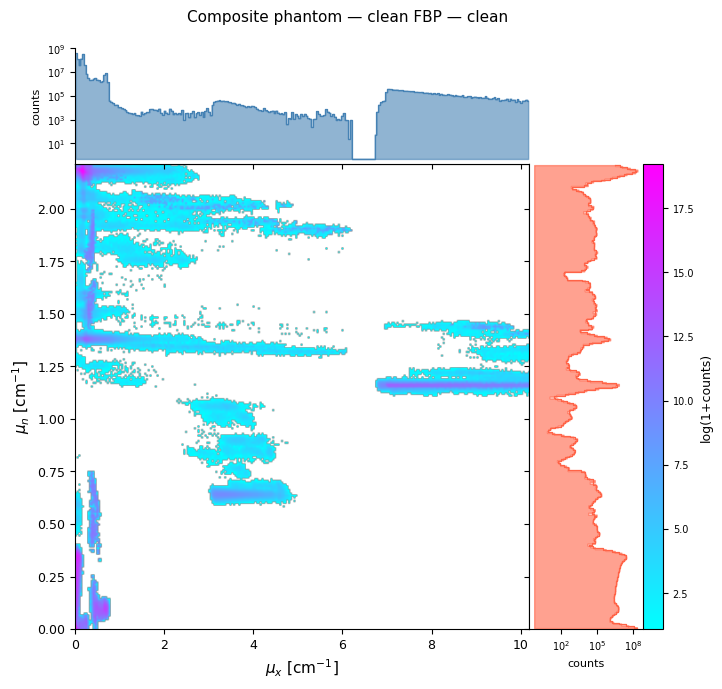

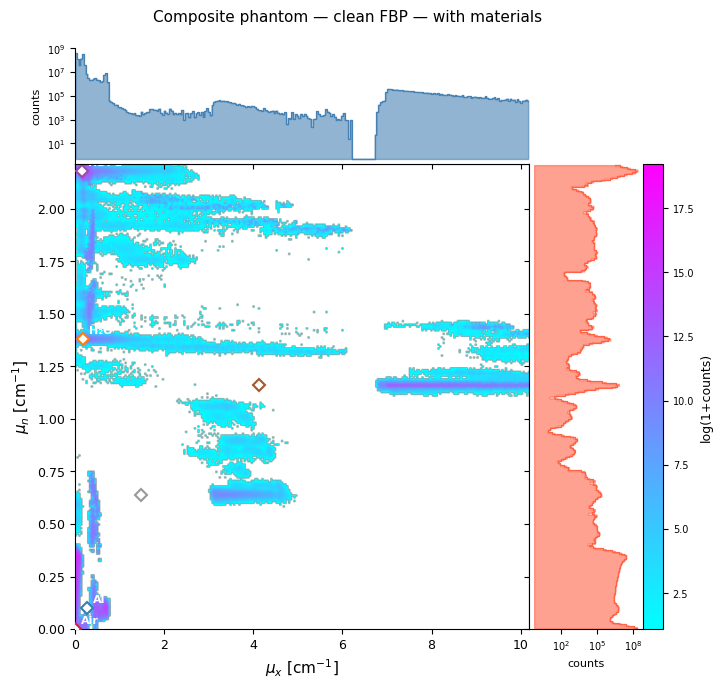

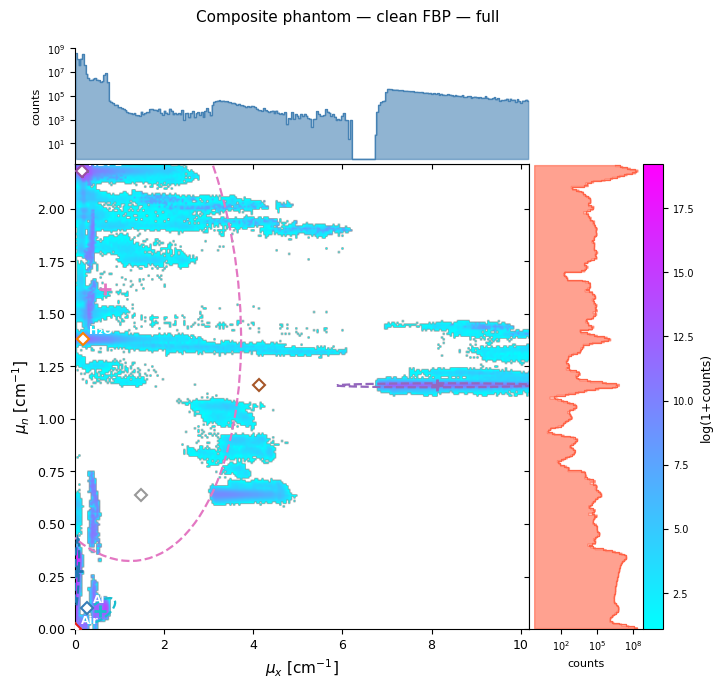

Wrote:
  outputs_FBP/composite_FBP_clean_clean.png
  outputs_FBP/composite_FBP_clean_materials.png
  outputs_FBP/composite_FBP_clean_full.png
  outputs_FBP/composite_FBP_clean_metrics.csv


In [2]:
# Example 1: clean composite phantom — three figures + CSV
# ───────────────────────────────────────────────────────────
# This is the canonical "is everything wired up" call.  It runs a small
# clean simulation, fits a 6-component GMM, computes both the v1 GMM-based
# and v3 label-anchored quality metrics, and writes:
#
#   {output_name}_clean.png      bimodal histogram, no annotations
#   {output_name}_materials.png  + ground-truth material markers
#   {output_name}_full.png       + GMM ellipses
#   {output_name}_metrics.csv    full metric table
#
# Use N=64 for a quick smoke test; bump N=512 or 1024 for figures.

import warnings; warnings.filterwarnings('ignore')
from neutron_xray_sim.simulation import DualModalitySimulation
from neutron_xray_sim.artifacts  import ArtifactConfig

sim = DualModalitySimulation(
    preset="composite", N=1024, n_angles=1200,
    algorithm="FBP", verbose=False,
)
res = sim.run(ArtifactConfig.clean(), tag="clean")

result = analyse_volume_pair(
    vol_xray    = res.vol_xray,
    vol_neutron = res.vol_neutron,
    phantom_obj = sim.phantom,
    bins        = 256,
    output_name = "composite_FBP_clean",   # → composite_FBP_clean_{clean,materials,full}.png + .csv
    output_dir  = "outputs_FBP",                # files go to outputs/ in CWD
    figsize     = (7, 7),                   # square panels
    title       = "Composite phantom — clean FBP",
)

print("Wrote:", *result["output_paths"].values(), sep="\n  ")


[projector] Projecting 1200 angles (ASTRA GPU) …
  → X-ray (polychromatic) …
  → Neutron (thermal) …
[projector] Done.
[reconstructor] Reconstructing with SIRT …
  -> X-ray …
  -> Neutron …
[reconstructor] Done.
[analyse]  direct arrays
           shape=(1024, 1024, 1024)  dtype=float32
           μ_x range [0.000, 7.509] cm⁻¹
           μ_n range [0.000, 2.208] cm⁻¹
           output stem: outputs_SIRT/composite_SIRT_clean
           Computing histogram  bins=256…
           Total voxels: 1,073,741,824
           Fitting GMM  k=6…
           GMM: k=6  BIC=-459915  AIC=-460224
           Computing shape signatures…
           Computing GMM-based metrics  (k=6)…
           Computing label-anchored metrics  (mode='label_anchored')…
           Label-anchored CE  : 1.0803 cm⁻¹
           Label-anchored DB  : 0.5185

 Section     Eq                                      Metric GMM (v1) Label-anchored (v3)                           Notes
   Shape  (1.2)                S_h  Horizontal streak s

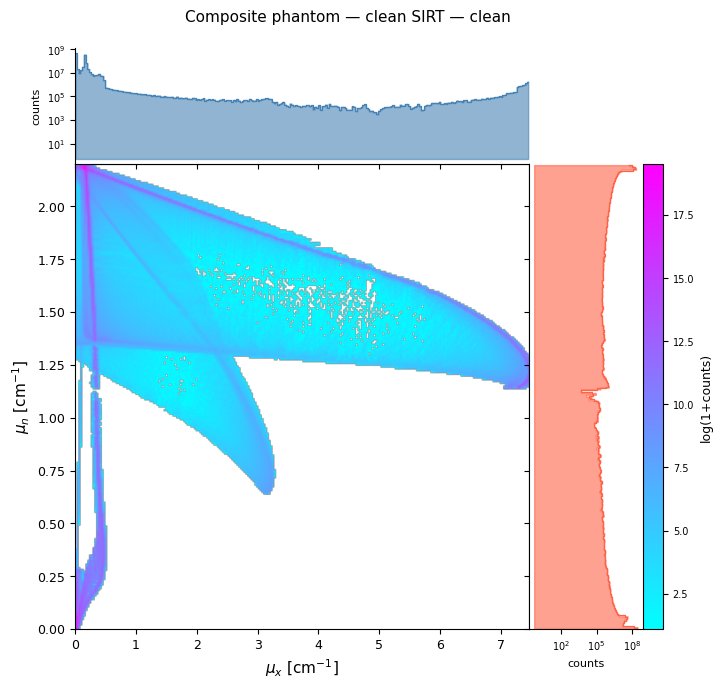

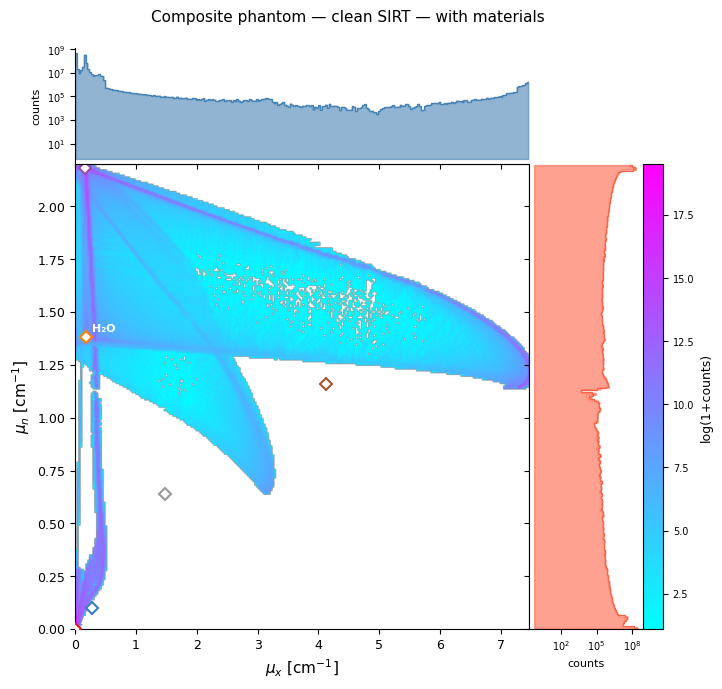

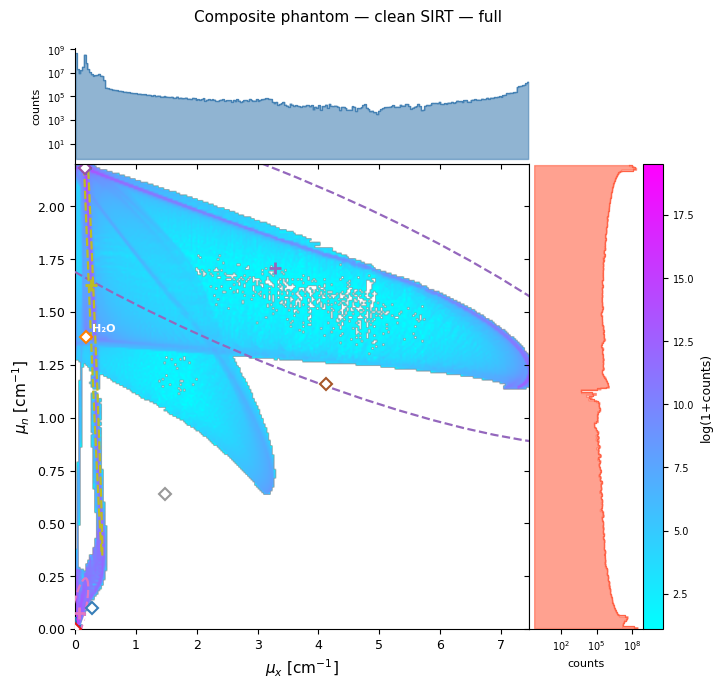

Wrote:
  outputs_SIRT/composite_SIRT_clean_clean.png
  outputs_SIRT/composite_SIRT_clean_materials.png
  outputs_SIRT/composite_SIRT_clean_full.png
  outputs_SIRT/composite_SIRT_clean_metrics.csv


In [3]:
# Example 1: clean composite phantom — three figures + CSV
# ───────────────────────────────────────────────────────────
# This is the canonical "is everything wired up" call.  It runs a small
# clean simulation, fits a 6-component GMM, computes both the v1 GMM-based
# and v3 label-anchored quality metrics, and writes:
#
#   {output_name}_clean.png      bimodal histogram, no annotations
#   {output_name}_materials.png  + ground-truth material markers
#   {output_name}_full.png       + GMM ellipses
#   {output_name}_metrics.csv    full metric table
#
# Use N=64 for a quick smoke test; bump N=512 or 1024 for figures.

import warnings; warnings.filterwarnings('ignore')
from neutron_xray_sim.simulation import DualModalitySimulation
from neutron_xray_sim.artifacts  import ArtifactConfig

sim = DualModalitySimulation(
    preset="composite", N=1024, n_angles=1200,
    algorithm="SIRT", verbose=False,
)
res = sim.run(ArtifactConfig.clean(), tag="clean")

result = analyse_volume_pair(
    vol_xray    = res.vol_xray,
    vol_neutron = res.vol_neutron,
    phantom_obj = sim.phantom,
    bins        = 256,
    output_name = "composite_SIRT_clean",   # → composite_FBP_clean_{clean,materials,full}.png + .csv
    output_dir  = "outputs_SIRT",                # files go to outputs/ in CWD
    figsize     = (7, 7),                   # square panels
    title       = "Composite phantom — clean SIRT",
)

print("Wrote:", *result["output_paths"].values(), sep="\n  ")


[projector] Projecting 1200 angles (ASTRA GPU) …
  → X-ray (polychromatic) …
  → Neutron (thermal) …
[projector] Done.
[reconstructor] Reconstructing with SART …
  -> X-ray …
  -> Neutron …
[reconstructor] Done.
[analyse]  direct arrays
           shape=(1024, 1024, 1024)  dtype=float32
           μ_x range [0.000, 8.527] cm⁻¹
           μ_n range [0.000, 2.679] cm⁻¹
           output stem: outputs_SART/composite_SART_clean
           Computing histogram  bins=256…
           Total voxels: 1,073,741,824
           Fitting GMM  k=6…
           GMM: k=6  BIC=-97020  AIC=-97328
           Computing shape signatures…
           Computing GMM-based metrics  (k=6)…
           Computing label-anchored metrics  (mode='label_anchored')…
           Label-anchored CE  : 1.1069 cm⁻¹
           Label-anchored DB  : 0.6387

 Section     Eq                                      Metric GMM (v1) Label-anchored (v3)                           Notes
   Shape  (1.2)                S_h  Horizontal streak sco

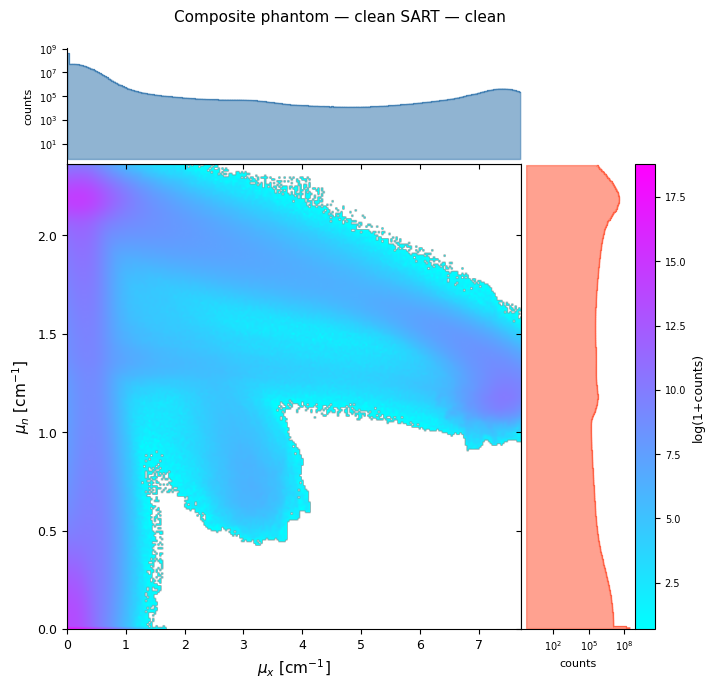

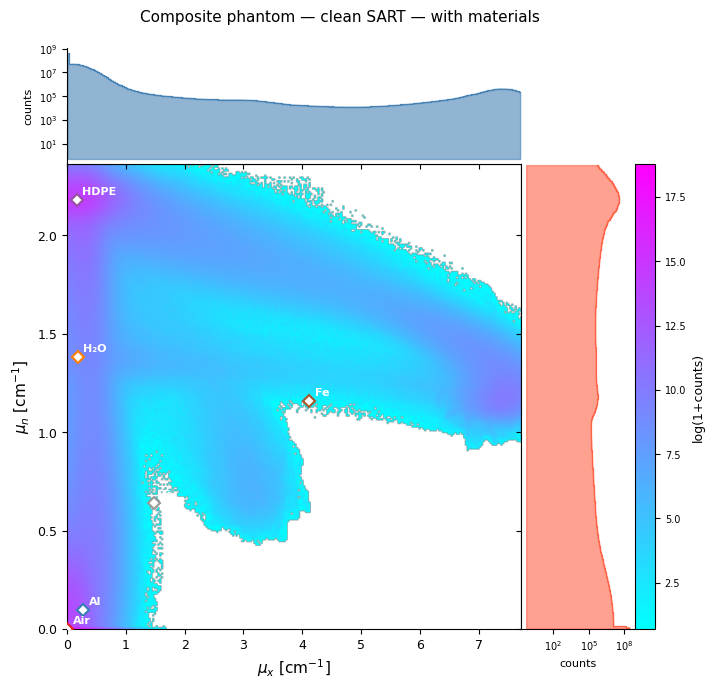

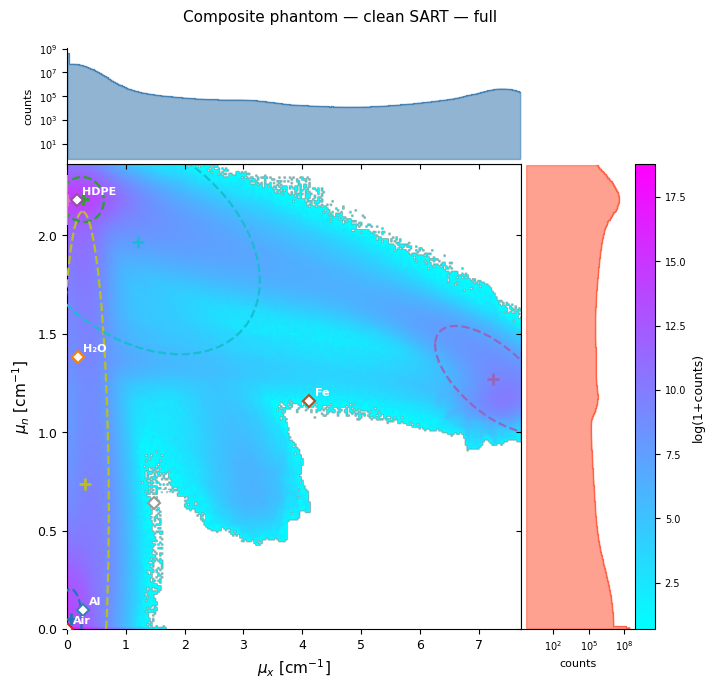

Wrote:
  outputs_SART/composite_SART_clean_clean.png
  outputs_SART/composite_SART_clean_materials.png
  outputs_SART/composite_SART_clean_full.png
  outputs_SART/composite_SART_clean_metrics.csv


In [4]:
# Example 1: clean composite phantom — three figures + CSV
# ───────────────────────────────────────────────────────────
# This is the canonical "is everything wired up" call.  It runs a small
# clean simulation, fits a 6-component GMM, computes both the v1 GMM-based
# and v3 label-anchored quality metrics, and writes:
#
#   {output_name}_clean.png      bimodal histogram, no annotations
#   {output_name}_materials.png  + ground-truth material markers
#   {output_name}_full.png       + GMM ellipses
#   {output_name}_metrics.csv    full metric table
#
# Use N=64 for a quick smoke test; bump N=512 or 1024 for figures.

import warnings; warnings.filterwarnings('ignore')
from neutron_xray_sim.simulation import DualModalitySimulation
from neutron_xray_sim.artifacts  import ArtifactConfig

sim = DualModalitySimulation(
    preset="composite", N=1024, n_angles=1200,
    algorithm="SART", verbose=False,
)
res = sim.run(ArtifactConfig.clean(), tag="clean")

result = analyse_volume_pair(
    vol_xray    = res.vol_xray,
    vol_neutron = res.vol_neutron,
    phantom_obj = sim.phantom,
    bins        = 256,
    output_name = "composite_SART_clean",   # → composite_FBP_clean_{clean,materials,full}.png + .csv
    output_dir  = "outputs_SART",                # files go to outputs/ in CWD
    figsize     = (7, 7),                   # square panels
    title       = "Composite phantom — clean SART",
)

print("Wrote:", *result["output_paths"].values(), sep="\n  ")


[projector] Projecting 1200 angles (ASTRA GPU) …
  → X-ray (polychromatic) …
  → Neutron (thermal) …
[projector] Done.
[reconstructor] Reconstructing with CGLS …
  -> X-ray …
  -> Neutron …
[reconstructor] Done.
[analyse]  direct arrays
           shape=(1024, 1024, 1024)  dtype=float32
           μ_x range [0.000, 13.051] cm⁻¹
           μ_n range [0.000, 2.445] cm⁻¹
           output stem: outputs_CGLS/composite_CGLS_clean
           Computing histogram  bins=256…
           Total voxels: 1,073,741,824
           Fitting GMM  k=6…
           GMM: k=6  BIC=-492614  AIC=-492922
           Computing shape signatures…
           Computing GMM-based metrics  (k=6)…
           Computing label-anchored metrics  (mode='label_anchored')…
           Label-anchored CE  : 1.3009 cm⁻¹
           Label-anchored DB  : 0.2074

 Section     Eq                                      Metric GMM (v1) Label-anchored (v3)                           Notes
   Shape  (1.2)                S_h  Horizontal streak 

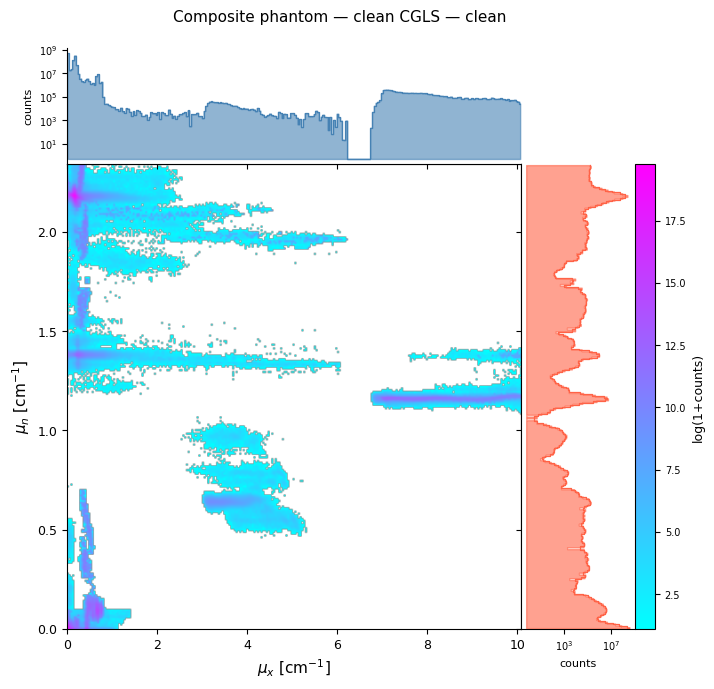

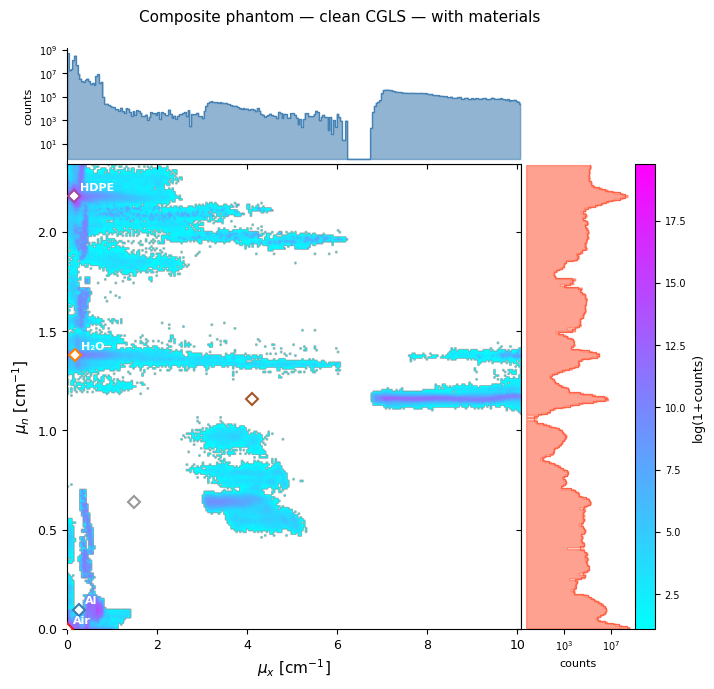

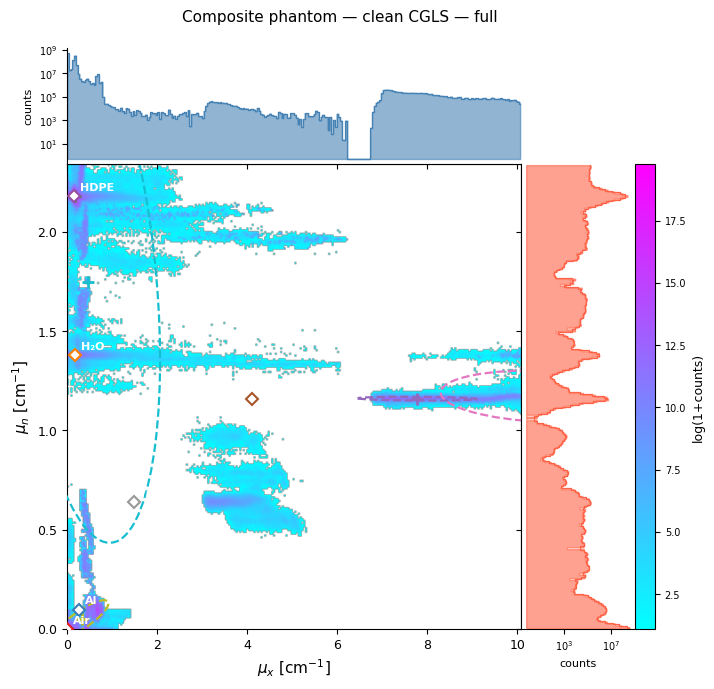

Wrote:
  outputs_CGLS/composite_CGLS_clean_clean.png
  outputs_CGLS/composite_CGLS_clean_materials.png
  outputs_CGLS/composite_CGLS_clean_full.png
  outputs_CGLS/composite_CGLS_clean_metrics.csv


In [5]:
# Example 1: clean composite phantom — three figures + CSV
# ───────────────────────────────────────────────────────────
# This is the canonical "is everything wired up" call.  It runs a small
# clean simulation, fits a 6-component GMM, computes both the v1 GMM-based
# and v3 label-anchored quality metrics, and writes:
#
#   {output_name}_clean.png      bimodal histogram, no annotations
#   {output_name}_materials.png  + ground-truth material markers
#   {output_name}_full.png       + GMM ellipses
#   {output_name}_metrics.csv    full metric table
#
# Use N=64 for a quick smoke test; bump N=512 or 1024 for figures.

import warnings; warnings.filterwarnings('ignore')
from neutron_xray_sim.simulation import DualModalitySimulation
from neutron_xray_sim.artifacts  import ArtifactConfig

sim = DualModalitySimulation(
    preset="composite", N=1024, n_angles=1200,
    algorithm="CGLS", verbose=False,
)
res = sim.run(ArtifactConfig.clean(), tag="clean")

result = analyse_volume_pair(
    vol_xray    = res.vol_xray,
    vol_neutron = res.vol_neutron,
    phantom_obj = sim.phantom,
    bins        = 256,
    output_name = "composite_CGLS_clean",   # → composite_FBP_clean_{clean,materials,full}.png + .csv
    output_dir  = "outputs_CGLS",                # files go to outputs/ in CWD
    figsize     = (7, 7),                   # square panels
    title       = "Composite phantom — clean CGLS",
)

print("Wrote:", *result["output_paths"].values(), sep="\n  ")


## Example 2 — dirty run with reference and per-region table
When a clean reference is supplied, Δ_n becomes meaningful. `morphology_mode='morphology_explore'` additionally returns a per-region summary table for anomaly detection.

In [ ]:
# Example 2: dirty run with reference + per-region table
# ──────────────────────────────────────────────────────────
# When a clean reference is provided, the Δ_n shape metric becomes
# meaningful (it measures the upward shift of the neutron marginal
# caused by scatter build-up).  Setting morphology_mode="morphology_explore"
# additionally returns a per-(material, spatial-region) summary that you
# can use for anomaly detection.

res_clean = sim.run(ArtifactConfig.clean(),     tag="clean")
res_dirty = sim.run(ArtifactConfig.realistic(), tag="realistic")

result = analyse_volume_pair(
    vol_xray        = res_dirty.vol_xray,
    vol_neutron     = res_dirty.vol_neutron,
    ref_vol_xray    = res_clean.vol_xray,
    ref_vol_neutron = res_clean.vol_neutron,
    phantom_obj     = sim.phantom,
    bins            = 96,
    morphology_mode = "morphology_explore",
    output_name     = "composite_FBP_realistic",
    output_dir      = "outputs",
    figsize         = (7, 7),
    title           = "Composite phantom — realistic FBP",
)

print(f"\n{len(result['region_summaries'])} region summaries returned:")
for s in result["region_summaries"][:8]:
    print(f"  {s.material:>8s}  reg{s.region_id:<3d}  "
          f"n_int={s.n_voxels_interior:>7d}  "
          f"centroid=({s.centroid_attn[0]:.2f},{s.centroid_attn[1]:.2f})  "
          f"ε_k,r = {s.eps_k:.3f}")
